In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy import stats
import xml.etree.ElementTree as ET
import urllib.request
import gzip
import io
import plotly.express as px
import plotly.graph_objects as go

!pip install plotly

# Chargement des données

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = (
    "https://raw.githubusercontent.com/OpenExoplanetCatalogue/"
    "oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"
)

df = pd.read_csv(CSV_URL, comment='#')

# On renomme les colonnes pour la lisibilité
COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

df.columns = COLS[:len(df.columns)]

df.isnull().sum().sort_values(ascending=False)

print(f"Nombre de planètes chargées : {len(df)}")
print(f"\nColonnes disponibles :\n{df.dtypes}")

Nombre de planètes chargées : 5414

Colonnes disponibles :
name                      object
binary_flag                int64
mass                     float64
radius                   float64
period                   float64
semi_major_axis          float64
eccentricity             float64
periastron               float64
longitude                float64
ascending_node           float64
inclination              float64
surface_temp             float64
age                      float64
discovery_method          object
discovery_year           float64
last_updated              object
ra_string                 object
dec_string                object
distance_pc              float64
host_star_mass           float64
host_star_radius         float64
host_star_metallicity    float64
host_star_temp           float64
host_star_age            float64
list_flag                 object
dtype: object


In [4]:
# Charge le fichier XML compressé
url = "https://github.com/OpenExoplanetCatalogue/oec_gzip/raw/master/systems.xml.gz"
oec = ET.parse(gzip.GzipFile(fileobj=io.BytesIO(urllib.request.urlopen(url).read())))

# Parcours de tous les systèmes et planètes
data = []
for system in oec.findall(".//system"):
    # Distance du système
    distance = system.findtext("distance")

    for planet in system.findall(".//planet"):
        # Récupère les valeurs avec leurs incertitudes
        mass_elem = planet.find("mass")
        radius_elem = planet.find("radius")

        mass = mass_elem.text if mass_elem is not None else None
        radius = radius_elem.text if radius_elem is not None else None

        # Incertitudes (attributs errorminus et errorplus)
        mass_err_min = mass_elem.get("errorminus") if mass_elem is not None else None
        mass_err_max = mass_elem.get("errorplus") if mass_elem is not None else None
        radius_err_min = radius_elem.get("errorminus") if radius_elem is not None else None
        radius_err_max = radius_elem.get("errorplus") if radius_elem is not None else None

        data.append({
            "name": planet.findtext("name"),
            "mass": mass,
            "mass_err_min": mass_err_min,
            "mass_err_max": mass_err_max,
            "radius": radius,
            "radius_err_min": radius_err_min,
            "radius_err_max": radius_err_max,
            "period": planet.findtext("period"),
            "discovery_method": planet.findtext("discoverymethod"),
            "discovery_year": planet.findtext("discoveryyear"),
            "distance": distance,
        })

# Stocké dans df_xml pour ne pas écraser le df principal chargé depuis le CSV
df_xml = pd.DataFrame(data)
print(f"Nombre de planètes : {len(df_xml)}")
print(df_xml.head())

Nombre de planètes : 5414
       name   mass mass_err_min mass_err_max radius radius_err_min  \
0  11 Com b   19.4          1.5          1.5   None           None   
1  11 UMi b  11.20        0.245        0.245   None           None   
2  14 And b    4.8         None         None   None           None   
3  14 Her b  4.975         None         None   None           None   
4  14 Her c  7.679         None         None   None           None   

  radius_err_max  period discovery_method discovery_year distance  
0           None  326.03               RV           2008     88.9  
1           None  516.22               RV           2009    122.1  
2           None  185.84               RV           2008     79.2  
3           None    1766               RV           2002     18.1  
4           None    9886               RV           2006     18.1  


In [5]:
for col in ['mass', 'radius', 'period', 'semi_major_axis', 'distance',
            'host_star_mass', 'host_star_radius', 'host_star_temp',
            'host_star_metallicity', 'host_star_age', 'surface_temp',
            'age', 'discovery_year', 'eccentricity', 'inclination']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[
    (df['mass'] > 0) &
    (df['host_star_mass'] > 0)
]

In [6]:
print(df.shape)

df.head()

(2634, 25)


,name,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,...,last_updated,ra_string,dec_string,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age,list_flag
1,HD 154857 b,0,2.24000,NaN,408.60000,1.291,0.46,57.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
2,HD 154857 c,0,2.58000,NaN,3452.00000,5.360,0.06,352.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
7,KMT-2019-BLG-1339L b,0,1.25000,NaN,NaN,2.150,NaN,NaN,NaN,NaN,...,20/09/03,17 42 58,-25 34 26,6120.000,0.480,NaN,NaN,NaN,NaN,Confirmed planets
8,KMT-2019-BLG-1715 b,0,2.56000,NaN,NaN,3.320,NaN,NaN,NaN,NaN,...,21/04/02,18 01 29.00,-28 46 38.00,3860.000,0.760,NaN,NaN,NaN,NaN,Confirmed planets
9,TOI-1685 b,0,0.01189,0.152,0.66914,NaN,NaN,NaN,NaN,NaN,...,21/03/03,04 34 23.00,+43 02 13.00,37.609,0.495,0.492,-0.13,3434.0,NaN,Confirmed planets


In [7]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

age                      2633
longitude                2592
ascending_node           2588
host_star_age            2140
periastron               1705
inclination              1360
surface_temp             1297
radius                   1129
eccentricity              687
host_star_metallicity     503
host_star_radius          468
semi_major_axis           334
host_star_temp            322
period                    253
distance_pc                34
discovery_method            9
ra_string                   9
dec_string                  9
discovery_year              8
last_updated                3
name                        0
host_star_mass              0
binary_flag                 0
mass                        0
list_flag                   0
dtype: int64

In [8]:
df.describe()

,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,inclination,surface_temp,age,discovery_year,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age
count,2634.000000,2634.000000,1505.000000,2.381000e+03,2300.000000,1947.000000,929.000000,42.000000,46.000000,1274.000000,1337.000000,1.0000,2626.000000,2600.000000,2634.000000,2166.000000,2131.000000,2312.000000,494.000000
mean,0.118451,2.124582,0.719350,4.309770e+03,8.446810,0.145421,133.806572,158.416349,88.165156,84.344809,952.924020,0.0055,2015.459634,679.646527,0.957619,2.086898,0.033874,5320.847491,4.852462
std,0.472182,6.857034,0.545634,1.648472e+05,168.704274,0.186049,118.562759,130.434680,86.917816,18.294876,613.816835,NaN,8.401275,1532.348235,0.451678,5.020811,0.288195,1308.088013,4.722504
min,0.000000,0.000008,0.016438,9.070629e-02,0.004420,-0.129287,-233.000000,-174.640000,-5.112604,-0.000543,96.400000,0.0055,1781.000000,1.295000,0.010000,0.000014,-2.090000,58.370000,0.002000
25%,0.000000,0.028300,0.207000,4.007232e+00,0.049900,0.000000,50.873000,45.375000,4.820000,85.355000,486.900000,0.0055,2011.000000,45.562100,0.750000,0.790000,-0.090000,4843.250000,2.192500
50%,0.000000,0.465000,0.616000,1.322260e+01,0.130900,0.077000,124.000000,183.089854,67.340000,88.000000,867.000000,0.0055,2017.000000,149.585000,0.960500,1.040500,0.051000,5513.000000,4.200000
75%,0.000000,1.920000,1.169000,2.689400e+02,1.320000,0.210000,220.860000,258.400000,148.932500,89.230000,1333.000000,0.0055,2021.000000,490.825000,1.145520,1.481750,0.190000,5900.000000,6.775000
max,2.000000,263.000000,6.000000,8.040000e+06,6471.000000,0.956000,791.000000,339.300000,320.800000,177.300000,7112.000000,0.0055,2023.000000,8500.000000,9.100000,86.400000,7.790000,29300.000000,80.000000


In [9]:
# On prépare un DataFrame de mapping avec le nom et les erreurs
uncertainty_map = df_xml[['name', 'mass_err_min', 'mass_err_max', 'radius_err_min', 'radius_err_max']].copy()

# On convertit en numérique 
for col in ['mass_err_min', 'mass_err_max', 'radius_err_min', 'radius_err_max']:
    uncertainty_map[col] = pd.to_numeric(uncertainty_map[col], errors='coerce')

# Fusion avec df principal
df = pd.merge(df, uncertainty_map, on='name', how='left')

# Acte I : Des lois dans la chaos ?

## La chaos en apparence

In [11]:
# Nettoyage et conversion 
def ra_to_degree(ra_str):
    if pd.isna(ra_str): return np.nan
    parts = str(ra_str).split()
    if len(parts) < 3: return np.nan
    return (float(parts[0]) + float(parts[1])/60 + float(parts[2])/3600) * 15

def dec_to_degree(dec_str):
    if pd.isna(dec_str): return np.nan
    parts = str(dec_str).split()
    if len(parts) < 3: return np.nan
    sign = -1 if '-' in parts[0] else 1
    return sign * (abs(float(parts[0])) + float(parts[1])/60 + float(parts[2])/3600)

# Application des fonctions (on garde les noms d'origine pour l'affichage)
df['ra_deg'] = df['ra_string'].apply(ra_to_degree)
df['dec_deg'] = df['dec_string'].apply(dec_to_degree)

# Construction
fig = px.scatter_geo(
    df,
    lat='dec_deg',
    lon='ra_deg',
    color='distance_pc',
    size='host_star_mass', 
    hover_name='name',  
    hover_data={           
        'ra_deg': ':.2f',
        'dec_deg': ':.2f',
        'distance_pc': ':.1f',
        'host_star_mass': ':.2f',
        'discovery_method': True 
    },
    color_continuous_scale='RdBu_r', #rainbow scall bleu au rouge (plus chaud) avec shift lineaire
    projection="hammer"
)

fig.update_geos(
    showcoastlines=False, 
    showland=False, 
    showocean=False,
    showlakes=False,
    bgcolor='#050505', 
    framecolor='white',
    lataxis_gridcolor='rgba(255, 255, 255, 0.1)',
    lonaxis_gridcolor='rgba(255, 255, 255, 0.1)',
    lataxis_showgrid=True,
    lonaxis_showgrid=True
)

fig.update_layout(
    paper_bgcolor='#050505',
    font_color="white",
    font_family="monospace",
    margin=dict(l=0, r=0, t=80, b=0),
    title_x=0.5,
    title_font_size=24
)

fig.show()

En observant la répartition des exoplanètes découvertes, on pourrait croire que l’espace n'est qu’un immense chaos, un désordre d’étoiles jetées au hasard. Pourtant, nous savons aujourd'hui qu’il n’en est rien : c’est précisément cet ordre caché et la logique de ces systèmes que la science s’efforce de décrypter depuis toutes ces années.

## Masse vs rayon : la relation fondamentale des exoplanètes

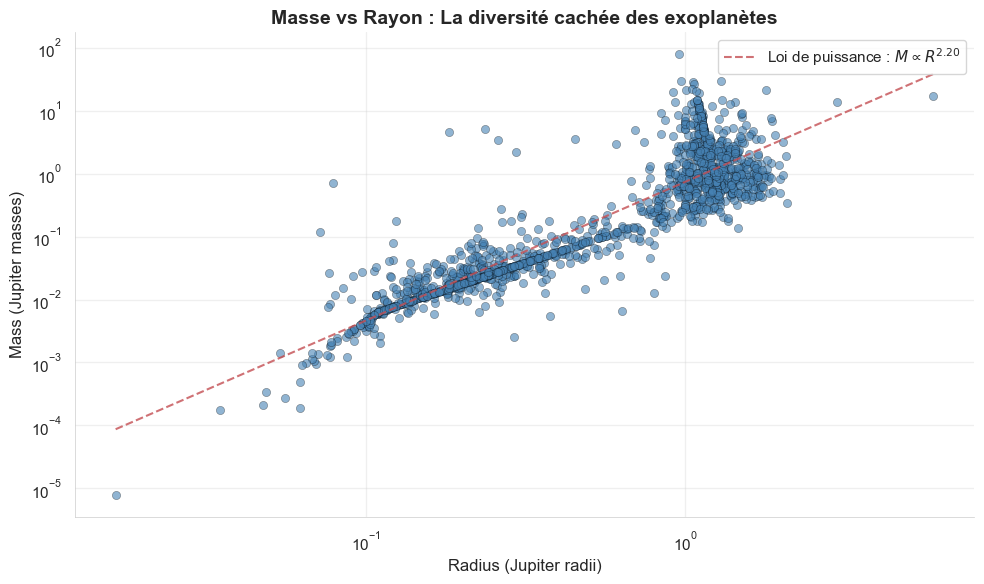

In [70]:

sns.scatterplot(
    data=df,
    x="radius",
    y="mass",
    alpha=0.6,
    s=35,
    color='steelblue',
    edgecolors='black',
    linewidth=0.3
)

# Régression linéaire sur les logs
df_clean = df.dropna(subset=["radius", "mass"])
df_clean = df_clean[(df_clean["radius"] > 0) & (df_clean["mass"] > 0)]

x_log = np.log10(df_clean["radius"])
y_log = np.log10(df_clean["mass"])

slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Tracé de la ligne de régression
x_fit = np.linspace(np.log10(df_clean["radius"].min()), np.log10(df_clean["radius"].max()), 100)
y_fit = intercept + slope * x_fit
plt.plot(10**x_fit, 10**y_fit, 'r--', linewidth=1.5, alpha=0.8,
         label=f'Loi de puissance : $M \\propto R^{{{slope:.2f}}}$')
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Radius (Jupiter radii)", fontsize=12)
plt.ylabel("Mass (Jupiter masses)", fontsize=12)
plt.title("Masse vs Rayon : La diversité cachée des exoplanètes", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.show()

La masse et le rayon des exoplanètes sont très corrélés. Ce graphique nous révèle une tendance claire. Plus une planète est massive, plus elle est grande. Mais la relation n'est pas linéaire. Elle suit une loi de puissance.

Si on regarde plus attentivement, les points ne se répartissent pas au hasard. On devine déjà plusieurs groupes : des planètes petites et denses (en bas à gauche), des planètes géantes (en haut à droite), et des objets intermédiaires. C'est cette intuition que nous formaliserons plus tard avec le clustering.

/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_63763/2594112860.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample['category'] = sample['radius'].apply(lambda x: categorize_planet(x)[0])
/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_63763/2594112860.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample['color'] = sample['radius'].apply(lambda x: categorize_planet(x)[1])
/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_63763/2594112860.py:27: SettingWithCopyW

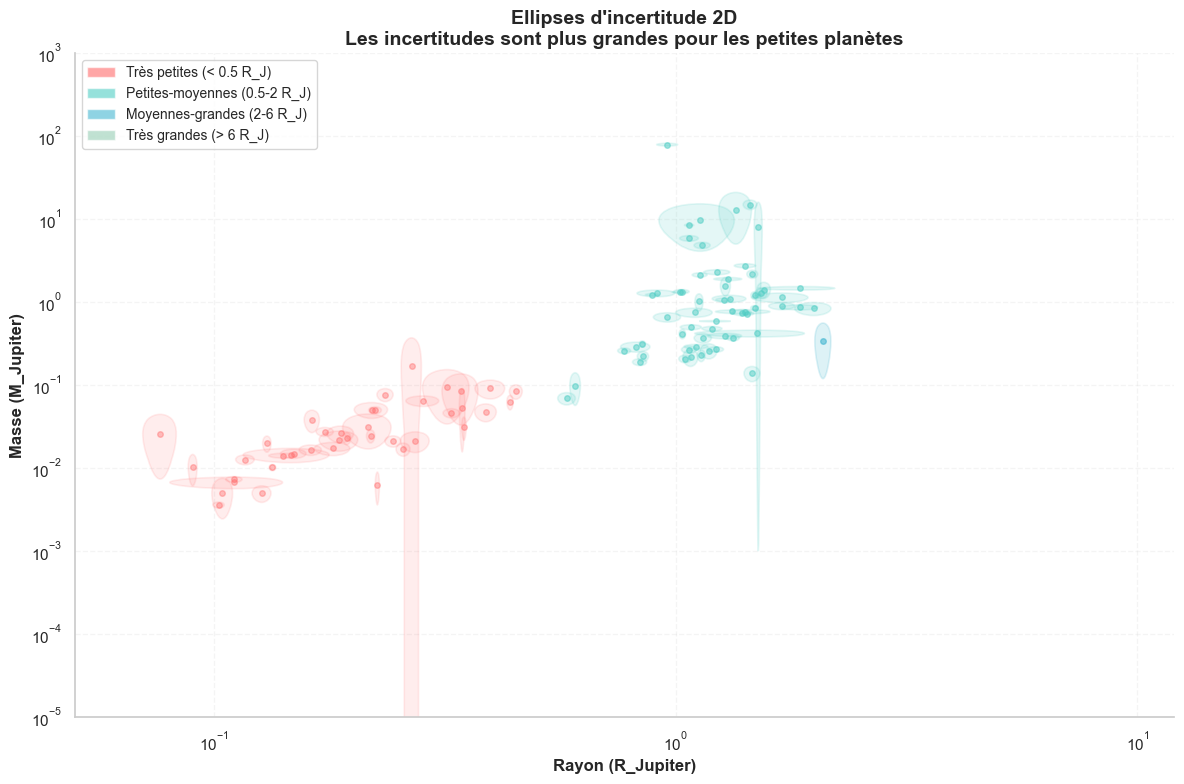

In [88]:


# Nettoie les données
df_err = df_xml.dropna(subset=['mass', 'radius']).copy()
df_err['mass'] = pd.to_numeric(df_err['mass'], errors='coerce')
df_err['radius'] = pd.to_numeric(df_err['radius'], errors='coerce')
df_err['mass_err_min'] = pd.to_numeric(df_err['mass_err_min'], errors='coerce')
df_err['mass_err_max'] = pd.to_numeric(df_err['mass_err_max'], errors='coerce')
df_err['radius_err_min'] = pd.to_numeric(df_err['radius_err_min'], errors='coerce')
df_err['radius_err_max'] = pd.to_numeric(df_err['radius_err_max'], errors='coerce')

df_err = df_err[(df_err['mass'] > 0) & (df_err['radius'] > 0)]
sample = df_err.dropna(subset=['mass_err_min', 'mass_err_max', 'radius_err_min', 'radius_err_max'])

# Stratification par catégories de rayon
# Cela montre comment l'incertitude varie avec la taille
def categorize_planet(radius):
    if radius < 0.5:
        return 'Très petites\n(< 0.5 R_J)', '#FF6B6B', 0.4
    elif radius < 2:
        return 'Petites-moyennes\n(0.5-2 R_J)', '#4ECDC4', 0.5
    elif radius < 6:
        return 'Moyennes-grandes\n(2-6 R_J)', '#45B7D1', 0.6
    else:
        return 'Très grandes\n(> 6 R_J)', '#96CEB4', 0.7

sample['category'] = sample['radius'].apply(lambda x: categorize_planet(x)[0])
sample['color'] = sample['radius'].apply(lambda x: categorize_planet(x)[1])
sample['alpha'] = sample['radius'].apply(lambda x: categorize_planet(x)[2])

fig, ax = plt.subplots(figsize=(12, 8))

# Utilise un sous-ensemble pour clarté
sample_subset = sample.sample(n=min(100, len(sample)), random_state=123)

for _, row in sample_subset.iterrows():
    x = row['radius']
    y = row['mass']
    
    # Largeur et hauteur de l'ellipse = 2 * erreur (pour ±1σ)
    width = 2 * (row['radius_err_min'] + row['radius_err_max']) / 2
    height = 2 * (row['mass_err_min'] + row['mass_err_max']) / 2
    
    # Crée l'ellipse d'incertitude
    ellipse = Ellipse((x, y), width, height,
                      alpha=row['alpha']*0.3, 
                      facecolor=row['color'],
                      edgecolor=row['color'],
                      linewidth=1.2)
    ax.add_patch(ellipse)
    
    # Point central
    ax.plot(x, y, 'o', color=row['color'], markersize=4, alpha=row['alpha'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Rayon (R_Jupiter)", fontsize=12, fontweight='bold')
ax.set_ylabel("Masse (M_Jupiter)", fontsize=12, fontweight='bold')
ax.set_title("Ellipses d'incertitude 2D\nLes incertitudes sont plus grandes pour les petites planètes",
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Légende des catégories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', alpha=0.6, label='Très petites (< 0.5 R_J)'),
    Patch(facecolor='#4ECDC4', alpha=0.6, label='Petites-moyennes (0.5-2 R_J)'),
    Patch(facecolor='#45B7D1', alpha=0.6, label='Moyennes-grandes (2-6 R_J)'),
    Patch(facecolor='#96CEB4', alpha=0.6, label='Très grandes (> 6 R_J)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_xlim(0.05, 12)
ax.set_ylim(10**-5, 10**3)

plt.tight_layout()
plt.show()


Les barres d’erreur montrent que les incertitudes sont plus dispersées pour les petites planètes ce qui reflète des difficultés observationnelles dans cette catégorie (faibles signaux, biais instrumentaux, etc.). Il y a une précision observationnelle plus faible pour les petites planètes, malgré une dispersion plus forte du nuage pour les grandes masses due à leur surreprésentation.

## La troisième loi de Kepler

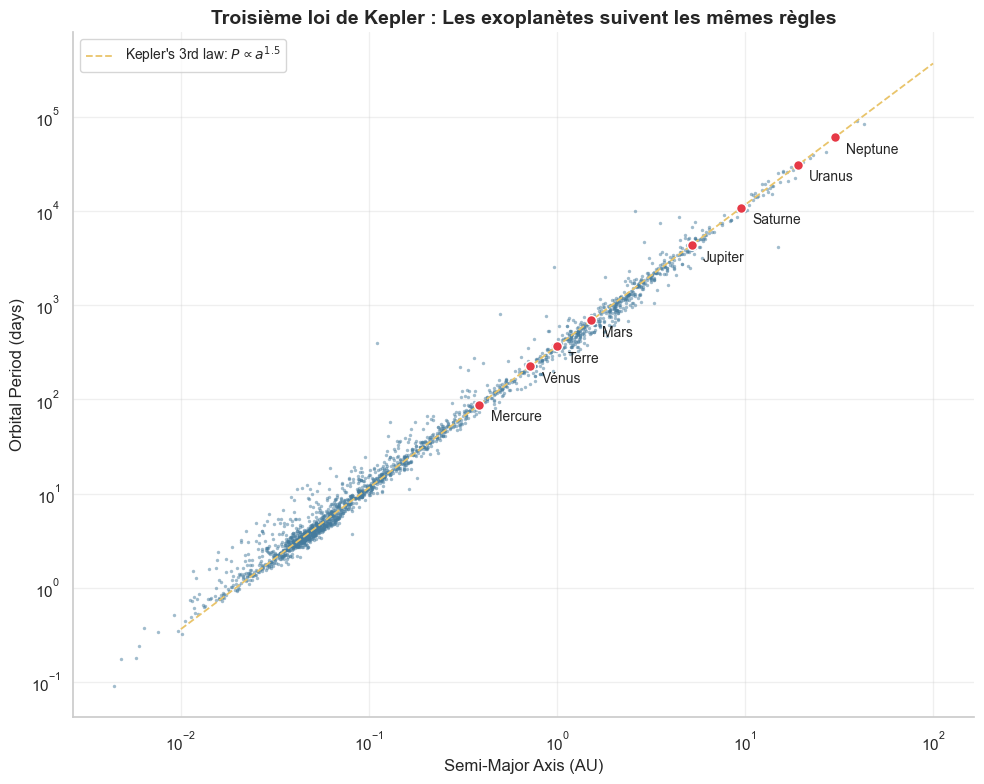

In [62]:
plt.figure(figsize=(10, 8))

if 'period' in df.columns and 'semi_major_axis' in df.columns:
    sub = df.dropna(subset=['period', 'semi_major_axis'])
    sub = sub[(sub['period'] > 0) & (sub['semi_major_axis'] > 0)]
    sub = sub[sub['period'] < 100000]

    plt.scatter(sub['semi_major_axis'], sub['period'],
                s=6, alpha=0.5, color='#457B9D', linewidths=0)

    # Loi de Kepler
    a_ref = np.logspace(-2, 2, 200)
    plt.plot(a_ref, 365.25 * a_ref**1.5, color='#E9C46A',
             lw=1.3, ls='--', label='Kepler\'s 3rd law: $P \\propto a^{1.5}$')

    # Planètes du Système Solaire
    solar_system = [
        ('Mercure', 0.387, 88),
        ('Vénus', 0.723, 225),
        ('Terre', 1.0, 365),
        ('Mars', 1.524, 687),
        ('Jupiter', 5.203, 4333),
        ('Saturne', 9.537, 10759),
        ('Uranus', 19.191, 30687),
        ('Neptune', 30.069, 60190)
    ]

    for name, a, p in solar_system:
        plt.scatter(a, p, s=50, color='#E63946', edgecolor='white', linewidth=1, zorder=5)
        plt.annotate(name, (a, p), fontsize=10, color='black', alpha=0.85,
                     xytext=(8, -4), textcoords='offset points', ha='left', va='top')

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("Semi-Major Axis (AU)", fontsize=12)
    plt.ylabel("Orbital Period (days)", fontsize=12)
    plt.title("Troisième loi de Kepler : Les exoplanètes suivent les mêmes règles", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

else:
    print(" Colonnes 'period' ou 'semi_major_axis' absentes")

plt.tight_layout()
plt.show()

Autre relation fondamentale : la période orbitale augmente avec la distance à l'étoile. La troisieme loi de kepler stipule que le carré de la période orbitale d'une planète est proportionnel au cube du demi-grand axe de son orbite. En appliquant une transformation logarithmique, on obtient une ligne droite. C'est exactement ce que l'on observe. Les exoplanètes suivent parfaitement cette loi, tout comme les planètes du Système Solaire. La physique est la même partout dans l'Univers.

## Température vs masse solaire

Nombre d'étoiles uniques : 1805
Températures : min=2516K, max=11327K


/var/folders/kz/jrt48myn5lv2h550w8pl7qvm0000gn/T/ipykernel_63763/3047786261.py:61: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/taniaadmane/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


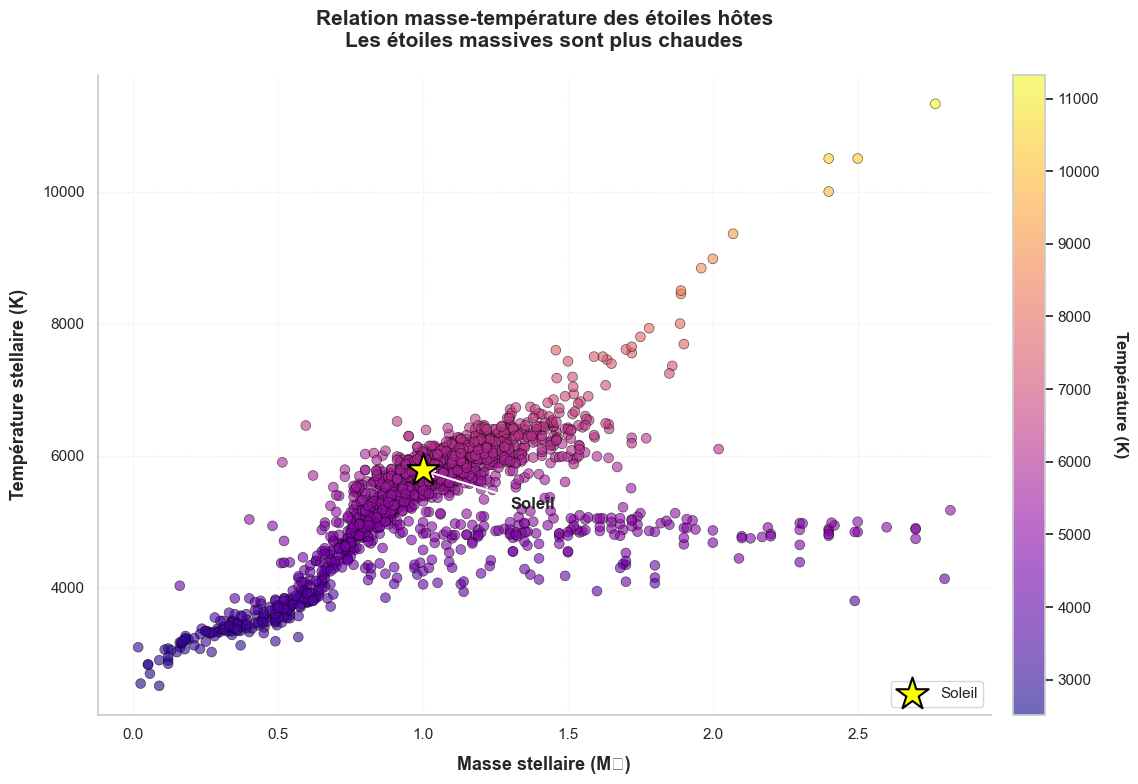

In [89]:
plt.figure(figsize=(12, 8))

# Filtrage et DEDUPLICATION : extraire le nom de l'étoile du nom de la planète
df['host_star_name'] = df['name'].str.rsplit(n=1).str[0]

df_stars = df.drop_duplicates(subset=["host_star_name"]).copy()
df_stars = df_stars[
    (df_stars["host_star_mass"] < 3) &
    (df_stars["host_star_temp"] > 2500) &
    (df_stars["host_star_temp"] < 15000)
]

print(f"Nombre d'étoiles uniques : {len(df_stars)}")
print(f"Températures : min={df_stars['host_star_temp'].min():.0f}K, max={df_stars['host_star_temp'].max():.0f}K")

# Scatter plot 
sc = plt.scatter(
    df_stars["host_star_mass"],
    df_stars["host_star_temp"],
    c=df_stars["host_star_temp"],
    cmap="plasma",
    alpha=0.6,
    s=50,
    edgecolors="black",
    linewidth=0.5
)

cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label("Température (K)", rotation=270, labelpad=20, fontsize=12, fontweight='bold')

# Axes
plt.xlabel("Masse stellaire (M☉)", fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel("Température stellaire (K)", fontsize=13, fontweight='bold', labelpad=10)
plt.title("Relation masse-température des étoiles hôtes\nLes étoiles massives sont plus chaudes",
          fontsize=15, fontweight='bold', pad=20)

# Marqueur Soleil
sun_mass = 1.0
sun_temp = 5778
plt.scatter(sun_mass, sun_temp, color='yellow', edgecolor='black', 
           marker='*', s=600, zorder=5, label='Soleil', linewidth=1.5)

plt.annotate(
    "Soleil", 
    xy=(sun_mass, sun_temp), 
    xytext=(1.3, 5200),
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5)
)

# Grille légère
plt.grid(True, alpha=0.2, linestyle='--')

# Épuration
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()


In [85]:
print(df.columns.tolist())

['name', 'binary_flag', 'mass', 'radius', 'period', 'semi_major_axis', 'eccentricity', 'periastron', 'longitude', 'ascending_node', 'inclination', 'surface_temp', 'age', 'discovery_method', 'discovery_year', 'last_updated', 'ra_string', 'dec_string', 'distance_pc', 'host_star_mass', 'host_star_radius', 'host_star_metallicity', 'host_star_temp', 'host_star_age', 'list_flag', 'mass_err_min', 'mass_err_max', 'radius_err_min', 'radius_err_max', 'ra_deg', 'dec_deg', 'ra_plot', 'dec_plot']


Les étoiles les plus massives sont aussi les plus chaudes. Cette relation, bien connue en astrophysique, est vérifiée dans notre catalogue. Elle rappelle que les propriétés des planètes sont très liées à celles de leur étoile.

## Distribution des masses stellaires

Mais malgré cette diversité de températures, notre échantillon reste centré sur les étoiles solaires. Un biais à ne pas oublier.

Points bleus (transit): 1327
Points oranges (RV): 1009
Points gris (autres): 298


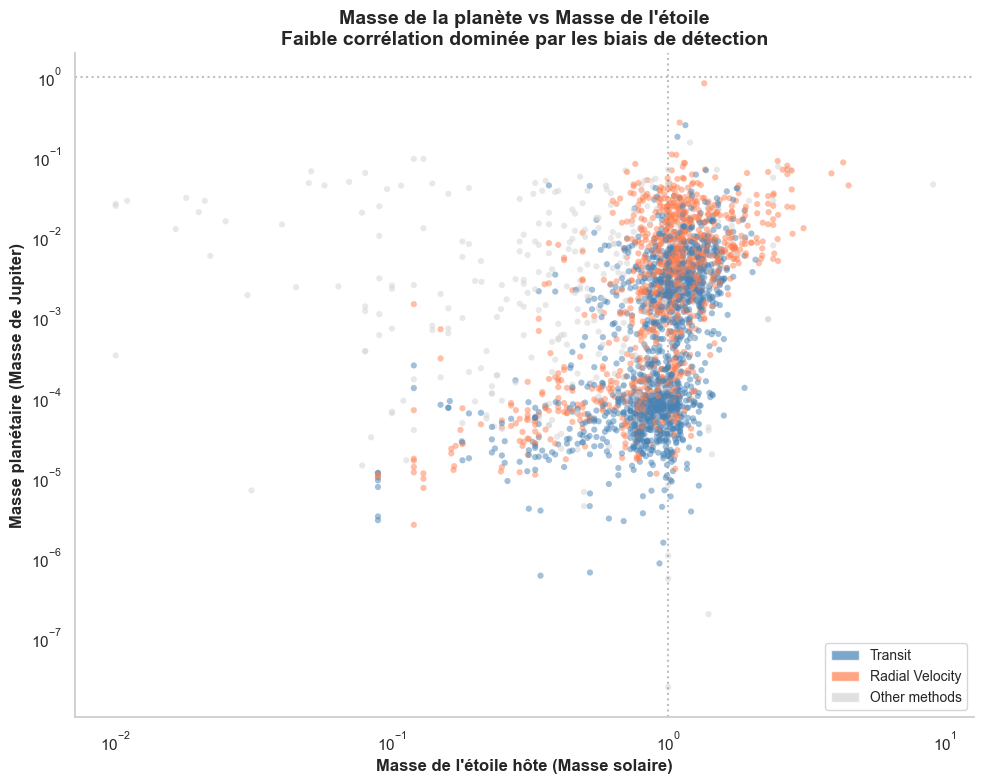

In [90]:

# on filtre les données
mask = df['mass'].notna() & df['host_star_mass'].notna() & (df['mass'] > 0) & (df['host_star_mass'] > 0)
sub = df[mask]

# Convertir en masses de Jupiter
sub['mass_jupiter'] = sub['mass'] / 318

# Fonction de couleur robuste
def get_color(method):
    if method is None:
        return 'lightgray'
    method_str = str(method).lower()
    if 'transit' in method_str:
        return 'steelblue'
    elif 'radial' in method_str or method_str == 'rv':
        return 'coral'
    else:
        return 'lightgray'

colors = sub['discovery_method'].map(get_color)

# Compter pour vérifier
print(f"Points bleus (transit): {sum(c == 'steelblue' for c in colors)}")
print(f"Points oranges (RV): {sum(c == 'coral' for c in colors)}")
print(f"Points gris (autres): {sum(c == 'lightgray' for c in colors)}")

plt.figure(figsize=(10, 8))

plt.scatter(sub['host_star_mass'], sub['mass_jupiter'], c=colors, alpha=0.5, s=20, edgecolors='none')

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Masse de l'étoile hôte (Masse solaire)", fontsize=12, fontweight='bold')
plt.ylabel("Masse planétaire (Masse de Jupiter)", fontsize=12, fontweight='bold')
plt.title("Masse de la planète vs Masse de l'étoile\nFaible corrélation dominée par les biais de détection",
          fontsize=14, fontweight='bold')

plt.axhline(y=1, linestyle=':', color='gray', alpha=0.5, label='Masse de Jupiter')
plt.axvline(x=1, linestyle=':', color='gray', alpha=0.5, label='Masse du Soleil')

legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Transit'),
    Patch(facecolor='coral', alpha=0.7, label='Radial Velocity'),
    Patch(facecolor='lightgray', alpha=0.7, label='Other methods')
]

plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

On remarque que la distribution des masses stellaires dans notre échantillon montre un pic autour d'une masse solaire. C'est pas un reflet de la réalité astrophysique (du genre les naines sont bien plus nombreuses dans la galaxie), mais c'est plutot un biais observationnel parce que les télescopes et les méthodes de détection ont été optimisés pour les étoiles de type solaire.

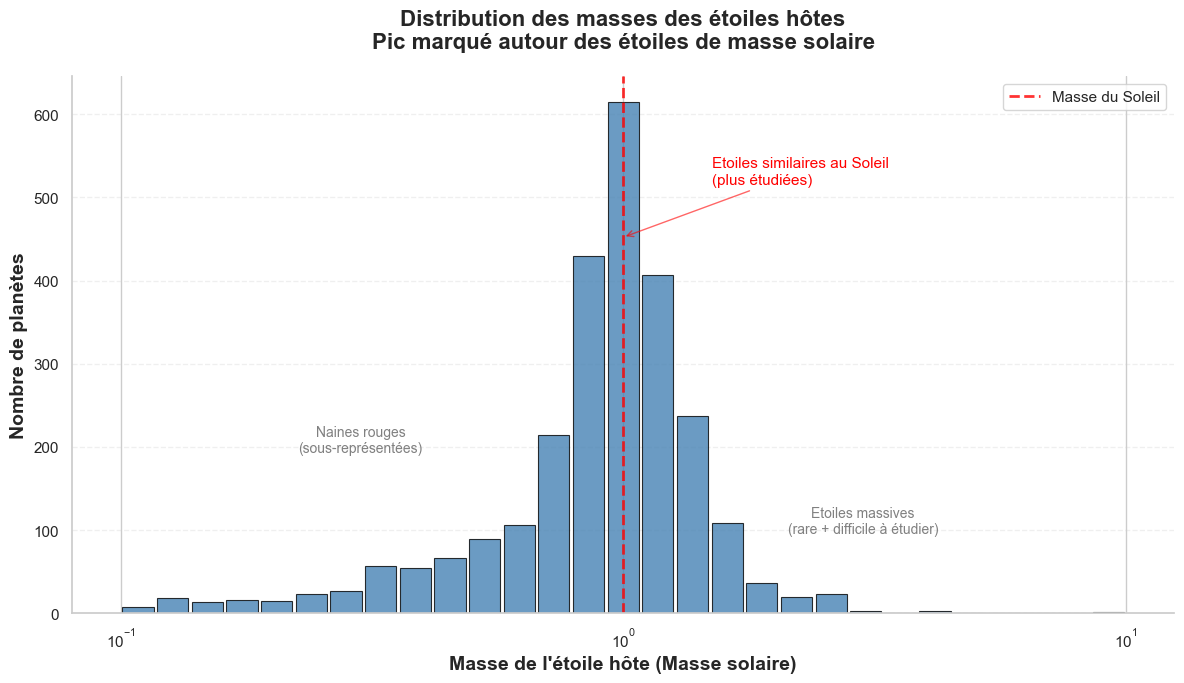

In [54]:
star_masses = df['host_star_mass'].dropna()
star_masses = star_masses[(star_masses > 0) & (star_masses < 10)]  # on enleve les extrêmes

plt.figure(figsize=(12, 7))

# Bins logarithmiques
bins_log = np.logspace(np.log10(0.1), np.log10(10), 30)

plt.hist(star_masses, bins=bins_log, color='steelblue', alpha=0.8,
         edgecolor='black', linewidth=0.8, rwidth=0.9)

plt.xscale('log')
plt.xlabel("Masse de l'étoile hôte (Masse solaire)", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de planètes", fontsize=14, fontweight='bold')
plt.title("Distribution des masses des étoiles hôtes\nPic marqué autour des étoiles de masse solaire",
          fontsize=16, fontweight='bold', pad=20)

# Ajouter une ligne verticale pour le Soleil
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Masse du Soleil')

# Annotations
plt.annotate('Etoiles similaires au Soleil \n(plus étudiées)', xy=(1, plt.ylim()[1]*0.7),
             xytext=(1.5, plt.ylim()[1]*0.8), fontsize=11, color='red',
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

plt.annotate('Naines rouges\n(sous-représentées)', xy=(0.3, plt.ylim()[1]*0.3),
             fontsize=10, color='gray', ha='center')

plt.annotate('Etoiles massives\n(rare + difficile à étudier)', xy=(3, plt.ylim()[1]*0.15),
             fontsize=10, color='gray', ha='center')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=11)

# Supprime les cadres du haut et droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Des géantes si proches ? L'énigme des Hot Jupiters

Parmi toutes les exoplanètes, une famille se distingue : les Hot Jupiters. Ces géantes gazeuses orbitent à moins de 0,1 UA de leur étoile, c'est à dire, vingt fois plus près que la Terre du Soleil. Leurs masses provoquent d'importantes perturbations de leur étoile hote (plus gros effet Doppler).Leur existence défie certaines théories de formation planétaire et illustre la diversité extrême des systèmes exoplanétaires.

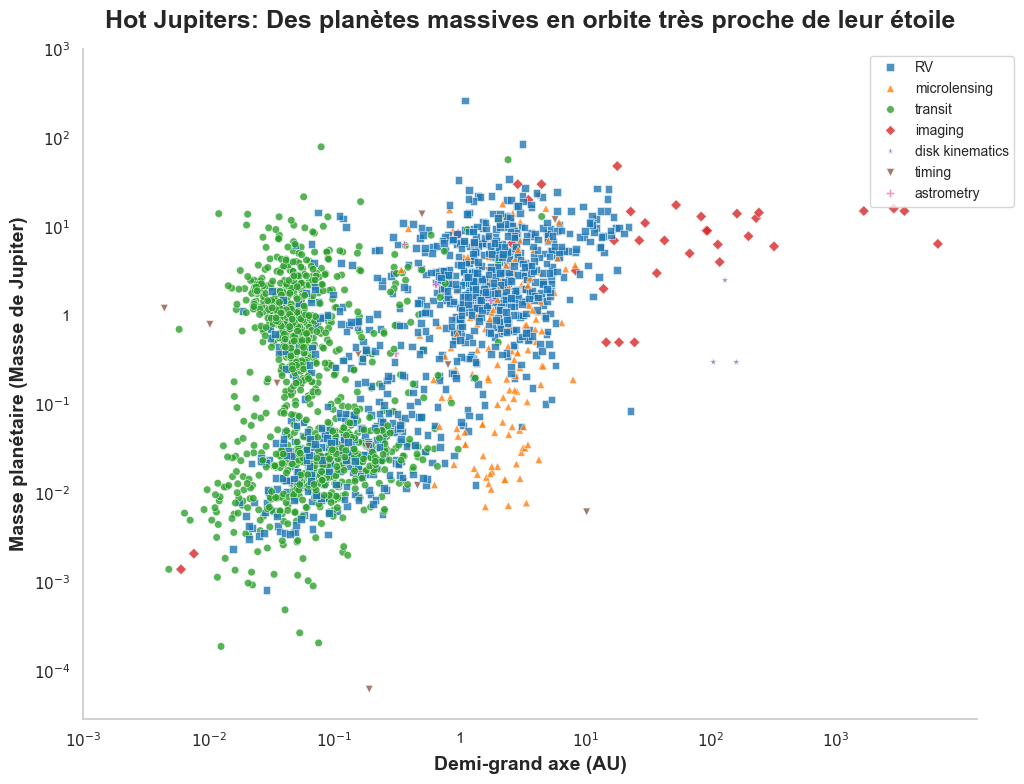

In [55]:
plt.figure(figsize=(12,8))

markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",
    "disk kinematics": "*",
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P"
}

# Palette de couleurs
methods = df['discovery_method'].unique()
palette = dict(zip(methods, sns.color_palette("tab10", n_colors=len(methods))))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="mass",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Demi-grand axe (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Masse planétaire (Masse de Jupiter)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Des planètes massives en orbite très proche de leur étoile",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

## À la recherche de mondes habitables

Parmi les milliers d'exoplanètes découvertes, une question fascine autant les scientifiques que le grand public : **certaines pourraient-elles abriter la vie ?**

La première condition est d'être située dans la zone habitable. C'est la région autour d'une étoile où la température permet à l'eau d'exister sous forme liquide en surface. Cette zone dépend de la luminosité (donc de la température) de l'étoile : plus l'étoile est chaude, plus sa zone habitable est éloignée.

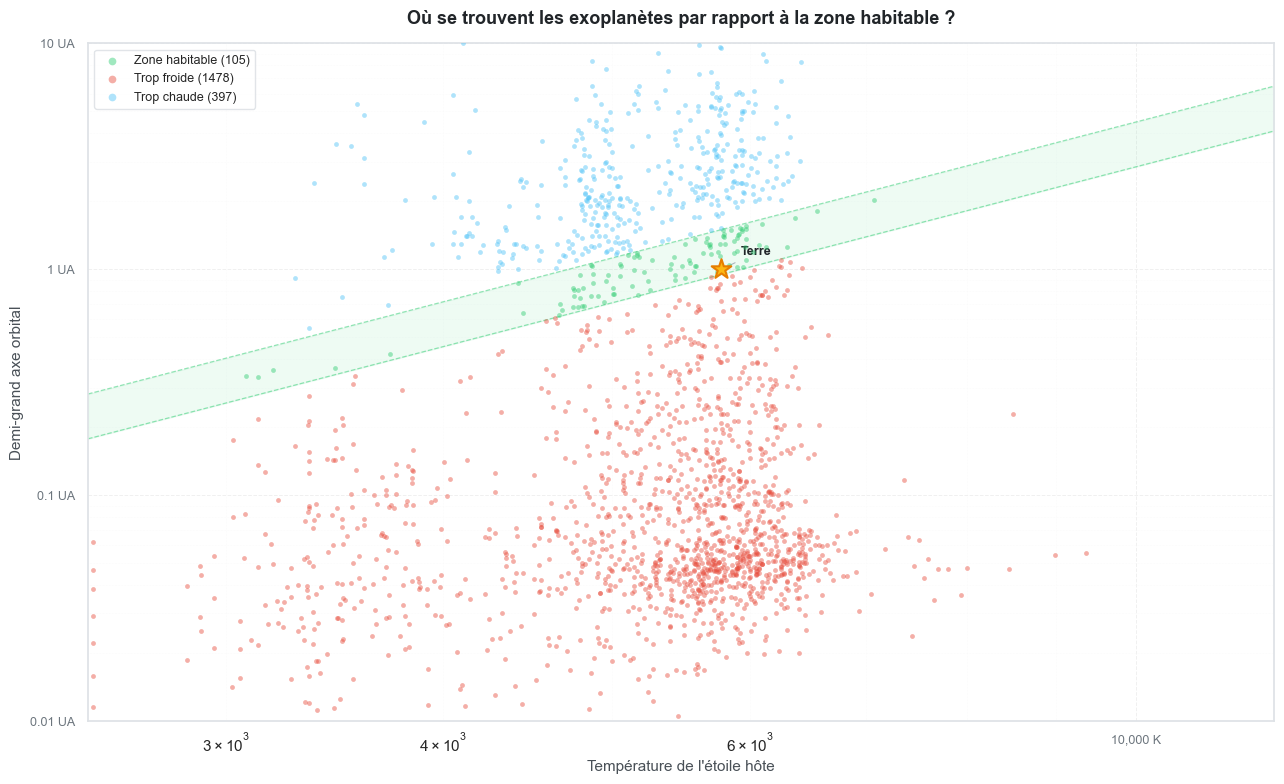

In [56]:
df_plot = df.dropna(subset=['host_star_temp', 'semi_major_axis']).copy()
df_plot = df_plot[(df_plot['host_star_temp'].between(2000, 15000)) &
                  (df_plot['semi_major_axis'].between(0.001, 10))]

factor     = (df_plot['host_star_temp'] / 5778) ** 2
hz_low_col = 0.95 * factor
hz_hi_col  = 1.50 * factor

conditions = [
    df_plot['semi_major_axis'].between(hz_low_col, hz_hi_col),
    df_plot['semi_major_axis'] < hz_low_col,
]
df_plot['zone'] = np.select(conditions, ['habitable', 'trop_chaud'], default='trop_froid')

# Style
STYLE = {
    'habitable': {'color': '#2ecc71', 'label': 'Zone habitable',  'zorder': 4},
    'trop_chaud': {'color': '#e74c3c', 'label': 'Trop froide',    'zorder': 3},
    'trop_froid': {'color': '#4FC3F7', 'label': 'Trop chaude',  'zorder': 3},
}

# Figure
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Zone habitable
temp_range = np.linspace(2500, 12000, 300)
hz_low  = 0.95 * (temp_range / 5778) ** 2
hz_high = 1.50 * (temp_range / 5778) ** 2
ax.fill_between(temp_range, hz_low, hz_high,
                color='#2ecc71', alpha=0.08, zorder=1)
ax.plot(temp_range, hz_low,  color='#2ecc71', linewidth=0.9, linestyle='--', alpha=0.5)
ax.plot(temp_range, hz_high, color='#2ecc71', linewidth=0.9, linestyle='--', alpha=0.5)

# Scatter par zone
for zone, style in STYLE.items():
    sub = df_plot[df_plot['zone'] == zone]
    ax.scatter(sub['host_star_temp'], sub['semi_major_axis'],
               color=style['color'], alpha=0.45, s=12,
               linewidths=0, label=f"{style['label']} ({len(sub)})",
               zorder=style['zorder'])

# Terre + Soleil
ax.scatter(5778, 1, s=220, color='#FDB813', edgecolors='#e67e00',
           linewidths=1.5, marker='*', zorder=6)
ax.annotate('Terre', xy=(5778, 1), xytext=(14, 10),
            textcoords='offset points', fontsize=9,
            fontweight='bold', color='#212529',
            arrowprops=dict(arrowstyle='-', color='#adb5bd', lw=0.8))

# Axes
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2500, 12000)
ax.set_ylim(0.01, 10)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,} K"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g} UA"))

ax.set_xlabel("Température de l'étoile hôte", fontsize=11, color='#495057')
ax.set_ylabel("Demi-grand axe orbital",        fontsize=11, color='#495057')
ax.tick_params(colors='#6c757d', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#dee2e6')

ax.grid(True, which='major', color='#f0f0f0', linewidth=0.7, linestyle='--')
ax.grid(True, which='minor', color='#f8f8f8', linewidth=0.4, linestyle=':')

# Titre
ax.set_title("Où se trouvent les exoplanètes par rapport à la zone habitable ?",
             fontsize=13, fontweight='bold', color='#212529', pad=14)

# Légende
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#dee2e6',
          loc='upper left', markerscale=1.6)

plt.tight_layout()
plt.show()

La majorité des planètes sont rouges (trop chaudes). Les points verts sont rares. Seulement une petite fraction des exoplanètes connues se situe dans la zone habitable théorique.

La zone habitable n'est qu'un premier critère. Elle ne garantit pas la présence d'eau liquide :

- L'atmosphère de la planète joue un rôle clé (effet de serre)
- L'activité stellaire (éruptions, rayonnement) peut rendre une planète inhabitable

Malgré ces limites, la zone habitable reste un filtre essentiel pour identifier les candidats les plus intéressants.

Ces observations nous ont donné une première carte du territoire. Mais peut-on aller plus loin et regrouper naturellement les exoplanètes en familles ? C'est ce que nous verrons dans l'Acte II.